## SELASTONE LOAN DEFAULT PREDICTION
Using Loan_Default.csv from Kaggle

**Compliance:** Explainable | Auditable | Policy-aligned | Privacy-compliant

## Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import randint, uniform, loguniform
import xgboost as xgb
import lightgbm as lgb
import shap
import pickle
import json
from pathlib import Path
import warnings
import os

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style("whitegrid")
print("✓ All imports successful")


✓ All imports successful


## Importing the dataset

In [2]:
csv_path = r"archive"

df = pd.read_csv(os.path.join(csv_path, 'Loan_Default.csv'))
print(f"✓ Data loaded: {df.shape}")
print(f"\nDataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst rows:")
print(df.head())


✓ Data loaded: (148670, 34)

Dataset shape: 148,670 rows × 34 columns

First rows:
      ID  year loan_limit             Gender approv_in_adv loan_type  \
0  24890  2019         cf  Sex Not Available         nopre     type1   
1  24891  2019         cf               Male         nopre     type2   
2  24892  2019         cf               Male           pre     type1   
3  24893  2019         cf               Male         nopre     type1   
4  24894  2019         cf              Joint           pre     type1   

  loan_purpose Credit_Worthiness open_credit business_or_commercial  ...  \
0           p1                l1        nopc                  nob/c  ...   
1           p1                l1        nopc                    b/c  ...   
2           p1                l1        nopc                  nob/c  ...   
3           p4                l1        nopc                  nob/c  ...   
4           p1                l1        nopc                  nob/c  ...   

   credit_type  Credit_Scor

## EXPLORE & CLEAN

In [3]:
print("\n" + "="*70)
print("DATA EXPLORATION & CLEANING")
print("="*70)

print(f"\nTarget Variable (Status):")
print(df['Status'].value_counts())
print(f"Default Rate: {df['Status'].mean():.2%}")

# Remove ID column
df = df.drop(['ID'], axis=1)

# Missing values
print(f"\nMissing Values Summary:")
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].head(15))

# Drop columns with >40% missing
drop_cols = missing_pct[missing_pct > 40].index.tolist()
print(f"\nDropping {len(drop_cols)} columns with >40% missing:")
print(drop_cols)
df = df.drop(columns=drop_cols)
print(f"\nDataset shape after cleaning: {df.shape}")



DATA EXPLORATION & CLEANING

Target Variable (Status):
Status
0    112031
1     36639
Name: count, dtype: int64
Default Rate: 24.64%

Missing Values Summary:
Upfront_charges              26.664425
Interest_rate_spread         24.644515
rate_of_interest             24.509989
dtir1                        16.224524
property_value               10.155378
LTV                          10.155378
income                        6.154571
loan_limit                    2.249277
approv_in_adv                 0.610749
submission_of_application     0.134526
age                           0.134526
loan_purpose                  0.090133
Neg_ammortization             0.081388
term                          0.027578
dtype: float64

Dropping 0 columns with >40% missing:
[]

Dataset shape after cleaning: (148670, 33)


## FEATURE ENGINEERING

In [4]:
print("\n" + "="*70)
print("FEATURE ENGINEERING")
print("="*70)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if 'Status' in numeric_cols:
    numeric_cols.remove('Status')

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

# Impute missing values
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f"\n✓ Missing values filled")

# Derived features
df['loan_to_income']   = df['loan_amount']  / (df['income']         + 1)
df['loan_to_property'] = df['loan_amount']  / (df['property_value'] + 1)
df['credit_to_income'] = df['Credit_Score'] / (df['income']         + 1)

new_features = ['loan_to_income', 'loan_to_property', 'credit_to_income']
numeric_cols.extend(new_features)

print(f"✓ Created {len(new_features)} derived features")
print(f"✓ Total numeric features: {len(numeric_cols)}")



FEATURE ENGINEERING
Numeric columns (11): ['year', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score', 'LTV', 'dtir1']

Categorical columns (21): ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region', 'Security_Type']

✓ Missing values filled
✓ Created 3 derived features
✓ Total numeric features: 14


## REMOVE LEAKY FEATURES

In [5]:
print("\n" + "="*70)
print("REMOVE LEAKY FEATURES")
print("="*70)

# These features are set AFTER the credit decision is made
# Including them lets the model read the answer from the question
LEAKY_FEATURES = [
    'Interest_rate_spread',  # priced per borrower risk tier → post-decision
    'rate_of_interest',      # actual rate charged → reflects risk already assessed
    'Upfront_charges',       # fees set based on risk tier → post-decision
]

df = df.drop(columns=[f for f in LEAKY_FEATURES if f in df.columns])
numeric_cols = [c for c in numeric_cols if c not in LEAKY_FEATURES]

print(f"Dropped {len(LEAKY_FEATURES)} leaky features: {LEAKY_FEATURES}")
print(f"Remaining numeric features: {len(numeric_cols)}")
print(f"Remaining total features: {df.shape[1]}")

print(f"\n⚠️  Expected outcome after retrain:")
print(f"  AUC will DROP from 1.0000 to somewhere realistic")
print(f"  Target range: 0.70 - 0.85 (good), 0.85+ (excellent)")



REMOVE LEAKY FEATURES
Dropped 3 leaky features: ['Interest_rate_spread', 'rate_of_interest', 'Upfront_charges']
Remaining numeric features: 11
Remaining total features: 33

⚠️  Expected outcome after retrain:
  AUC will DROP from 1.0000 to somewhere realistic
  Target range: 0.70 - 0.85 (good), 0.85+ (excellent)


## PREPARE FEATURES FOR MODELING

In [6]:
print("\n" + "="*70)
print("PREPARE FEATURES")
print("="*70)

X = df[numeric_cols + categorical_cols].copy()
y = df['Status'].copy()

print(f"Features shape: {X.shape}")
print(f"Target distribution:")
print(f"  0 (No Default): {(y == 0).sum():,}")
print(f"  1 (Default): {(y == 1).sum():,}")

# Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print(f"✓ Encoded {len(categorical_cols)} categorical columns")

# Clip outliers at 1st/99th percentiles
for col in numeric_cols:
    q1  = X[col].quantile(0.01)
    q99 = X[col].quantile(0.99)
    X[col] = X[col].clip(q1, q99)

print(f"✓ Handled outliers")
print(f"\nFinal features: {X.columns.tolist()}")



PREPARE FEATURES
Features shape: (148670, 32)
Target distribution:
  0 (No Default): 112,031
  1 (Default): 36,639
✓ Encoded 21 categorical columns
✓ Handled outliers

Final features: ['year', 'loan_amount', 'term', 'property_value', 'income', 'Credit_Score', 'LTV', 'dtir1', 'loan_to_income', 'loan_to_property', 'credit_to_income', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region', 'Security_Type']


## TRAIN-TEST SPLIT

In [7]:
print("\n" + "="*70)
print("TRAIN-TEST SPLIT")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"  Default rate: {y_train.mean():.2%}")
print(f"\nTest set: {X_test.shape}")
print(f"  Default rate: {y_test.mean():.2%}")

feature_names = X.columns.tolist()



TRAIN-TEST SPLIT
Training set: (118936, 32)
  Default rate: 24.64%

Test set: (29734, 32)
  Default rate: 24.65%


## SCALE FEATURES

In [8]:
print("\n" + "="*70)
print("SCALE FEATURES")
print("="*70)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✓ Features scaled (mean=0, std=1)")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")



SCALE FEATURES
✓ Features scaled (mean=0, std=1)
Training set shape: (118936, 32)
Test set shape: (29734, 32)


## HANDLE CLASS IMBALANCE

In [9]:
print("\n" + "="*70)
print("HANDLE CLASS IMBALANCE (SMOTE)")
print("="*70)

smote = SMOTE(
    k_neighbors=3,
    sampling_strategy=0.8,
    random_state=42
)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE:")
print(f"  Shape: {X_train_scaled.shape}")
print(f"  Defaults: {y_train.sum():,} ({y_train.mean():.2%})")
print(f"\nAfter SMOTE:")
print(f"  Shape: {X_train_balanced.shape}")
print(f"  Defaults: {y_train_balanced.sum():,} ({y_train_balanced.mean():.2%})")



HANDLE CLASS IMBALANCE (SMOTE)
Before SMOTE:
  Shape: (118936, 32)
  Defaults: 29,311 (24.64%)

After SMOTE:
  Shape: (161325, 32)
  Defaults: 71,700 (44.44%)


## HYPERPARAMETER TUNING — XGBOOST (RandomizedSearchCV)

In [10]:
print("\n" + "="*70)
print("HYPERPARAMETER TUNING — XGBOOST")
print("="*70)

xgb_tune_pipeline = ImbPipeline([
    ('smote', SMOTE(k_neighbors=3, sampling_strategy=0.8, random_state=42)),
    ('clf', xgb.XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    ))
])

xgb_param_dist = {
    'clf__n_estimators':     randint(200, 800),
    'clf__max_depth':        randint(3, 8),
    'clf__learning_rate':    uniform(0.01, 0.19),
    'clf__subsample':        uniform(0.6, 0.4),
    'clf__colsample_bytree': uniform(0.6, 0.4),
    'clf__min_child_weight': randint(1, 10),
    'clf__reg_lambda':       uniform(0.0, 3.0),
    'clf__reg_alpha':        uniform(0.0, 2.0),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_search = RandomizedSearchCV(
    xgb_tune_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

xgb_search.fit(X_train_scaled, y_train)

print(f"\n✓ Best CV ROC-AUC: {xgb_search.best_score_:.4f}")
print(f"✓ Best params:")
xgb_best_params = {}
for k, v in xgb_search.best_params_.items():
    clean_key = k.replace('clf__', '')
    xgb_best_params[clean_key] = v
    print(f"    {clean_key:<20} {v}")



HYPERPARAMETER TUNING — XGBOOST
Fitting 3 folds for each of 30 candidates, totalling 90 fits

✓ Best CV ROC-AUC: 0.8939
✓ Best params:
    colsample_bytree     0.6727299868828402
    learning_rate        0.044846856872152424
    max_depth            6
    min_child_weight     6
    n_estimators         452
    reg_alpha            0.8638900372842315
    reg_lambda           0.8736874205941257
    subsample            0.8447411578889518


## TRAIN XGBOOST

In [11]:
print("\n" + "="*70)
print("TRAIN XGBOOST MODEL")
print("="*70)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    **xgb_best_params,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

print(f"Training XGBoost with tuned hyperparameters (scale_pos_weight={scale_pos_weight:.2f})...")
xgb_model.fit(X_train_balanced, y_train_balanced)

print(f"✓ XGBoost model trained")
print(f"  Trees: {xgb_model.n_estimators}")
print(f"  Max depth: {xgb_model.max_depth}")



TRAIN XGBOOST MODEL
Training XGBoost with tuned hyperparameters (scale_pos_weight=3.06)...
✓ XGBoost model trained
  Trees: 452
  Max depth: 6


## EVALUATE XGBOOST MODEL

In [12]:
print("\n" + "="*70)
print("MODEL EVALUATION — XGBOOST")
print("="*70)

y_train_pred       = xgb_model.predict(X_train_scaled)
y_train_pred_proba = xgb_model.predict_proba(X_train_scaled)[:, 1]
y_test_pred        = xgb_model.predict(X_test_scaled)
y_test_pred_proba  = xgb_model.predict_proba(X_test_scaled)[:, 1]

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy  = accuracy_score(y_test,  y_test_pred)
train_f1       = f1_score(y_train, y_train_pred)
test_f1        = f1_score(y_test,  y_test_pred)
train_auc      = roc_auc_score(y_train, y_train_pred_proba)
test_auc       = roc_auc_score(y_test,  y_test_pred_proba)

print(f"Training Metrics:  Accuracy={train_accuracy:.4f}  F1={train_f1:.4f}  AUC={train_auc:.4f}")
print(f"Test Metrics:      Accuracy={test_accuracy:.4f}  F1={test_f1:.4f}  AUC={test_auc:.4f}")

cm = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(f"  TN={cm[0,0]:,}  FP={cm[0,1]:,}  FN={cm[1,0]:,}  TP={cm[1,1]:,}")
print(f"\n{classification_report(y_test, y_test_pred, target_names=['No Default', 'Default'])}")



MODEL EVALUATION — XGBOOST
Training Metrics:  Accuracy=0.8663  F1=0.7427  AUC=0.9165
Test Metrics:      Accuracy=0.8588  F1=0.7273  AUC=0.8990

Confusion Matrix:
  TN=19,939  FP=2,467  FN=1,730  TP=5,598

              precision    recall  f1-score   support

  No Default       0.92      0.89      0.90     22406
     Default       0.69      0.76      0.73      7328

    accuracy                           0.86     29734
   macro avg       0.81      0.83      0.82     29734
weighted avg       0.86      0.86      0.86     29734



### SHAP Explainability — XGBoost


SHAP EXPLAINABILITY — XGBOOST


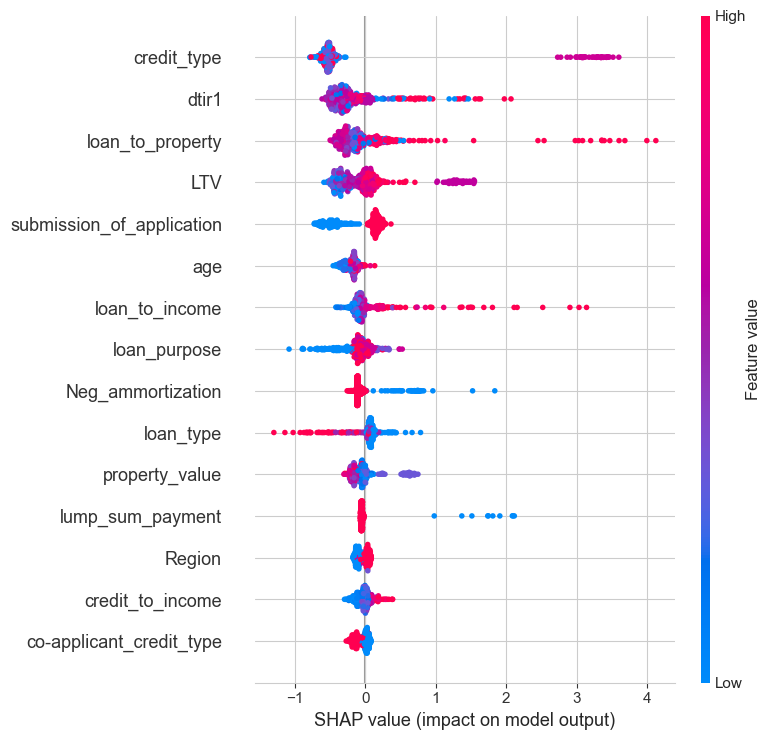

✓ XGBoost SHAP summary plot displayed


In [13]:
print("\n" + "="*70)
print("SHAP EXPLAINABILITY — XGBOOST")
print("="*70)

shap_idx = np.random.default_rng(42).choice(
    X_test_scaled.shape[0], size=min(500, X_test_scaled.shape[0]), replace=False
)
X_shap_sample = X_test_scaled[shap_idx]

xgb_explainer  = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(X_shap_sample)

shap.summary_plot(xgb_shap_values, X_shap_sample,
                  feature_names=feature_names, show=True, max_display=15)
print("✓ XGBoost SHAP summary plot displayed")


#### XGBOOST K-FOLD CROSS-VALIDATION

In [14]:
print("\n" + "="*70)
print("K-FOLD CROSS-VALIDATION — XGBOOST (k=5)")
print("="*70)

cv_scores = cross_val_score(
    xgb_model, X_train_scaled, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)
print(f"CV AUC scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")



K-FOLD CROSS-VALIDATION — XGBOOST (k=5)
CV AUC scores: [0.8977 0.8938 0.8996 0.896  0.894 ]
Mean: 0.8962  ±  0.0022


## HYPERPARAMETER TUNING — LIGHTGBM (RandomizedSearchCV)

In [15]:
print("\n" + "="*70)
print("HYPERPARAMETER TUNING — LIGHTGBM")
print("="*70)

lgb_tune_pipeline = ImbPipeline([
    ('smote', SMOTE(k_neighbors=3, sampling_strategy=0.8, random_state=42)),
    ('clf', lgb.LGBMClassifier(
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    ))
])

lgb_param_dist = {
    'clf__n_estimators':      randint(200, 800),
    'clf__num_leaves':        randint(20, 150),
    'clf__max_depth':         randint(3, 10),
    'clf__learning_rate':     uniform(0.01, 0.19),
    'clf__subsample':         uniform(0.6, 0.4),
    'clf__colsample_bytree':  uniform(0.6, 0.4),
    'clf__min_child_samples': randint(5, 50),
    'clf__reg_lambda':        uniform(0.0, 3.0),
    'clf__reg_alpha':         uniform(0.0, 2.0),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lgb_search = RandomizedSearchCV(
    lgb_tune_pipeline,
    param_distributions=lgb_param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

lgb_search.fit(X_train, y_train)

print(f"\n✓ Best CV ROC-AUC: {lgb_search.best_score_:.4f}")
print(f"✓ Best params:")
lgb_best_params = {}
for k, v in lgb_search.best_params_.items():
    clean_key = k.replace('clf__', '')
    lgb_best_params[clean_key] = v
    print(f"    {clean_key:<20} {v}")



HYPERPARAMETER TUNING — LIGHTGBM
Fitting 3 folds for each of 30 candidates, totalling 90 fits

✓ Best CV ROC-AUC: 0.8908
✓ Best params:
    colsample_bytree     0.9915571433100037
    learning_rate        0.10248100906229647
    max_depth            5
    min_child_samples    31
    n_estimators         425
    num_leaves           40
    reg_alpha            1.0052741862103842
    reg_lambda           1.7307116538790774
    subsample            0.7970070775275455


## TRAIN LIGHTGBM

In [16]:
print("\n" + "="*70)
print("TRAIN LIGHTGBM MODEL")
print("="*70)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgb_model = lgb.LGBMClassifier(
    **lgb_best_params,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print(f"Training LightGBM with tuned hyperparameters (scale_pos_weight={scale_pos_weight:.2f})...")
lgb_model.fit(X_train_balanced, y_train_balanced)
print(f"✓ LightGBM model trained")
print(f"  Trees: {lgb_model.n_estimators}")
print(f"  Max depth: {lgb_model.max_depth}")



TRAIN LIGHTGBM MODEL
Training LightGBM with tuned hyperparameters (scale_pos_weight=3.06)...
✓ LightGBM model trained
  Trees: 425
  Max depth: 5


## EVALUATE LIGHTGBM MODEL

In [17]:
print("\n" + "="*70)
print("MODEL EVALUATION — LIGHTGBM")
print("="*70)

lgb_test_pred       = lgb_model.predict(X_test)
lgb_test_pred_proba = lgb_model.predict_proba(X_test)[:, 1]

print(f"Test Metrics:")
print(f"  Accuracy : {accuracy_score(y_test, lgb_test_pred):.4f}")
print(f"  F1-Score : {f1_score(y_test, lgb_test_pred):.4f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, lgb_test_pred_proba):.4f}")
print(f"\n{classification_report(y_test, lgb_test_pred, target_names=['No Default', 'Default'])}")



MODEL EVALUATION — LIGHTGBM
Test Metrics:
  Accuracy : 0.2465
  F1-Score : 0.3954
  AUC-ROC  : 0.3688

              precision    recall  f1-score   support

  No Default       0.00      0.00      0.00     22406
     Default       0.25      1.00      0.40      7328

    accuracy                           0.25     29734
   macro avg       0.12      0.50      0.20     29734
weighted avg       0.06      0.25      0.10     29734



### SHAP Explainability — LightGBM


SHAP EXPLAINABILITY — LIGHTGBM


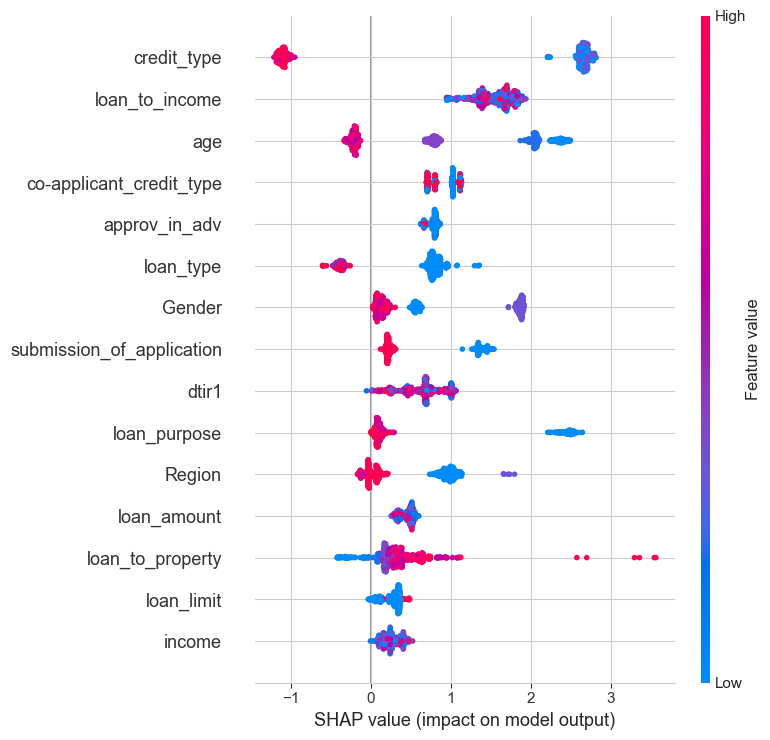

✓ LightGBM SHAP summary plot displayed


In [18]:
print("\n" + "="*70)
print("SHAP EXPLAINABILITY — LIGHTGBM")
print("="*70)

shap_idx_lgb = np.random.default_rng(42).choice(
    X_test.shape[0], size=min(500, X_test.shape[0]), replace=False
)
X_shap_lgb = X_test.values[shap_idx_lgb]

lgb_explainer   = shap.TreeExplainer(lgb_model)
lgb_shap_values = lgb_explainer.shap_values(X_shap_lgb)
if isinstance(lgb_shap_values, list):
    lgb_shap_values = lgb_shap_values[1]

shap.summary_plot(lgb_shap_values, X_shap_lgb,
                  feature_names=feature_names, show=True, max_display=15)
print("✓ LightGBM SHAP summary plot displayed")


## HYPERPARAMETER TUNING — LOGISTIC REGRESSION (RandomizedSearchCV)

In [19]:
print("\n" + "="*70)
print("HYPERPARAMETER TUNING — LOGISTIC REGRESSION")
print("="*70)

lr_tune_estimator = LogisticRegression(
    solver='saga',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

lr_param_dist = {
    'C':        loguniform(1e-3, 1e2),
    'penalty':  ['l1', 'l2'],
    'max_iter': [1000, 2000],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lr_search = RandomizedSearchCV(
    lr_tune_estimator,
    param_distributions=lr_param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

lr_search.fit(X_train_scaled, y_train)

print(f"\n✓ Best CV ROC-AUC: {lr_search.best_score_:.4f}")
print(f"✓ Best params:")
lr_best_params = dict(lr_search.best_params_)
for k, v in lr_best_params.items():
    print(f"    {k:<20} {v}")



HYPERPARAMETER TUNING — LOGISTIC REGRESSION
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✓ Best CV ROC-AUC: 0.7518
✓ Best params:
    C                    0.028888383623653185
    max_iter             2000
    penalty              l1


## TRAIN LOGISTIC REGRESSION

In [20]:
print("\n" + "="*70)
print("TRAIN LOGISTIC REGRESSION MODEL")
print("="*70)

lr_model = LogisticRegression(
    **lr_best_params,
    solver='saga',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

print("Training Logistic Regression...")
lr_model.fit(X_train_scaled, y_train)
print(f"✓ Logistic Regression model trained")
print(f"  Features: {lr_model.n_features_in_}")



TRAIN LOGISTIC REGRESSION MODEL
Training Logistic Regression...
✓ Logistic Regression model trained
  Features: 32


## EVALUATE LOGISTIC REGRESSION

In [21]:
print("\n" + "="*70)
print("MODEL EVALUATION — LOGISTIC REGRESSION")
print("="*70)

lr_test_pred       = lr_model.predict(X_test_scaled)
lr_test_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f"Test Metrics:")
print(f"  Accuracy : {accuracy_score(y_test, lr_test_pred):.4f}")
print(f"  F1-Score : {f1_score(y_test, lr_test_pred):.4f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, lr_test_pred_proba):.4f}")
print(f"\n{classification_report(y_test, lr_test_pred, target_names=['No Default', 'Default'])}")



MODEL EVALUATION — LOGISTIC REGRESSION
Test Metrics:
  Accuracy : 0.6991
  F1-Score : 0.5193
  AUC-ROC  : 0.7534

              precision    recall  f1-score   support

  No Default       0.86      0.71      0.78     22406
     Default       0.43      0.66      0.52      7328

    accuracy                           0.70     29734
   macro avg       0.65      0.69      0.65     29734
weighted avg       0.76      0.70      0.72     29734



## HYPERPARAMETER TUNING — RANDOM FOREST (RandomizedSearchCV)

In [22]:
print("\n" + "="*70)
print("HYPERPARAMETER TUNING — RANDOM FOREST")
print("="*70)

rf_tune_estimator = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

rf_param_dist = {
    'n_estimators':      randint(100, 500),
    'max_depth':         randint(5, 30),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2', 0.5],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    rf_tune_estimator,
    param_distributions=rf_param_dist,
    n_iter=25,
    scoring='roc_auc',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

rf_search.fit(X_train, y_train)

print(f"\n✓ Best CV ROC-AUC: {rf_search.best_score_:.4f}")
print(f"✓ Best params:")
rf_best_params = dict(rf_search.best_params_)
for k, v in rf_best_params.items():
    print(f"    {k:<20} {v}")



HYPERPARAMETER TUNING — RANDOM FOREST
Fitting 3 folds for each of 25 candidates, totalling 75 fits

✓ Best CV ROC-AUC: 0.8893
✓ Best params:
    max_depth            20
    max_features         0.5
    min_samples_leaf     8
    min_samples_split    15
    n_estimators         314


## TRAIN RANDOM FOREST

In [23]:
print("\n" + "="*70)
print("TRAIN RANDOM FOREST MODEL")
print("="*70)

rf_model = RandomForestClassifier(
    **rf_best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)
print(f"✓ Random Forest model trained")
print(f"  Features: {rf_model.n_features_in_}")



TRAIN RANDOM FOREST MODEL
Training Random Forest...
✓ Random Forest model trained
  Features: 32


## EVALUATE RANDOM FOREST

In [24]:
print("\n" + "="*70)
print("MODEL EVALUATION — RANDOM FOREST")
print("="*70)

rf_test_pred       = rf_model.predict(X_test)
rf_test_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"Test Metrics:")
print(f"  Accuracy : {accuracy_score(y_test, rf_test_pred):.4f}")
print(f"  F1-Score : {f1_score(y_test, rf_test_pred):.4f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, rf_test_pred_proba):.4f}")
print(f"\n{classification_report(y_test, rf_test_pred, target_names=['No Default', 'Default'])}")



MODEL EVALUATION — RANDOM FOREST
Test Metrics:
  Accuracy : 0.8900
  F1-Score : 0.7549
  AUC-ROC  : 0.8941

              precision    recall  f1-score   support

  No Default       0.90      0.96      0.93     22406
     Default       0.84      0.69      0.75      7328

    accuracy                           0.89     29734
   macro avg       0.87      0.82      0.84     29734
weighted avg       0.89      0.89      0.89     29734



## SAVE TUNED HYPERPARAMETERS

In [25]:
print("\n" + "="*70)
print("SAVE TUNED HYPERPARAMETERS")
print("="*70)

# Save all best params so retrain.py can load them — no re-tuning needed weekly
output_dir = Path('models')
output_dir.mkdir(exist_ok=True)

best_params_all = {
    "XGBoost":            xgb_best_params,
    "LightGBM":           lgb_best_params,
    "LogisticRegression": lr_best_params,
    "RandomForest":       rf_best_params,
}

with open(output_dir / 'best_hyperparams.json', 'w') as f:
    # Convert numpy types to native Python for JSON serialisation
    def convert(obj):
        if isinstance(obj, (np.integer,)):  return int(obj)
        if isinstance(obj, (np.floating,)): return float(obj)
        return obj
    json.dump(
        {model: {k: convert(v) for k, v in params.items()}
         for model, params in best_params_all.items()},
        f, indent=2
    )

print("✓ Best hyperparameters saved → models/best_hyperparams.json")
print(json.dumps(
    {model: {k: convert(v) for k, v in params.items()}
     for model, params in best_params_all.items()},
    indent=2
))



SAVE TUNED HYPERPARAMETERS
✓ Best hyperparameters saved → models/best_hyperparams.json
{
  "XGBoost": {
    "colsample_bytree": 0.6727299868828402,
    "learning_rate": 0.044846856872152424,
    "max_depth": 6,
    "min_child_weight": 6,
    "n_estimators": 452,
    "reg_alpha": 0.8638900372842315,
    "reg_lambda": 0.8736874205941257,
    "subsample": 0.8447411578889518
  },
  "LightGBM": {
    "colsample_bytree": 0.9915571433100037,
    "learning_rate": 0.10248100906229647,
    "max_depth": 5,
    "min_child_samples": 31,
    "n_estimators": 425,
    "num_leaves": 40,
    "reg_alpha": 1.0052741862103842,
    "reg_lambda": 1.7307116538790774,
    "subsample": 0.7970070775275455
  },
  "LogisticRegression": {
    "C": 0.028888383623653185,
    "max_iter": 2000,
    "penalty": "l1"
  },
  "RandomForest": {
    "max_depth": 20,
    "max_features": 0.5,
    "min_samples_leaf": 8,
    "min_samples_split": 15,
    "n_estimators": 314
  }
}


## MODEL COMPARISON & BEST MODEL SELECTION


MODEL COMPARISON — ALL FOUR MODELS

Model                   AUC-ROC       F1  Accuracy  Precision   Recall     TP     FN
------------------------------------------------------------------------------------
XGBoost                  0.8990   0.7273    0.8588     0.6941   0.7639   5598   1730
Random Forest            0.8941   0.7549    0.8900     0.8374   0.6872   5036   2292
Logistic Regression      0.7534   0.5193    0.6991     0.4283   0.6595   4833   2495
LightGBM                 0.3688   0.3954    0.2465     0.2465   1.0000   7328      0

🏆  WINNER: XGBoost
   AUC-ROC  : 0.8990
   F1-Score : 0.7273
   Accuracy : 0.8588
   Precision: 0.6941
   Recall   : 0.7639


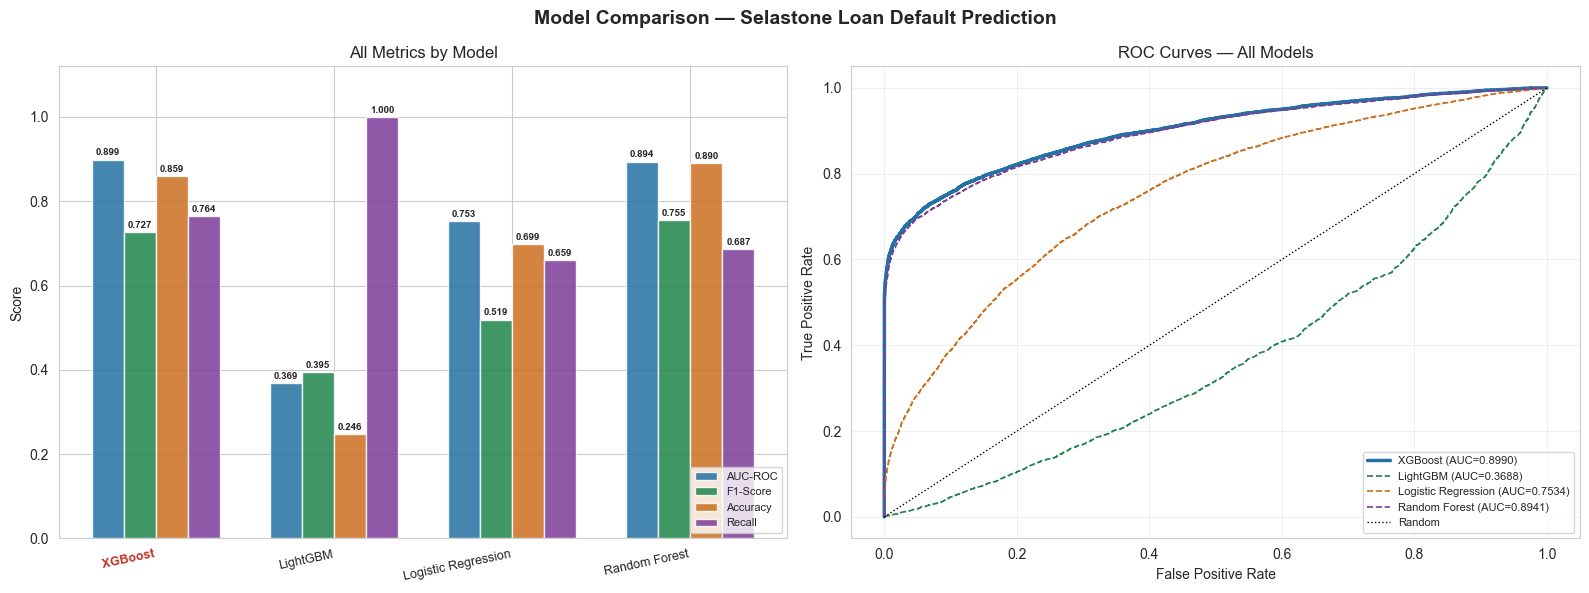

✓ Comparison chart saved: model_comparison.png


In [26]:
print("\n" + "="*70)
print("MODEL COMPARISON — ALL FOUR MODELS")
print("="*70)

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

def compute_metrics(model, X, y, label):
    y_pred       = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    cm_          = confusion_matrix(y, y_pred)
    tn_, fp_, fn_, tp_ = cm_.ravel()
    precision = tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 0.0
    recall    = tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0.0
    return {
        "model":     label,
        "accuracy":  round(accuracy_score(y, y_pred),     4),
        "f1":        round(f1_score(y, y_pred),           4),
        "auc":       round(roc_auc_score(y, y_pred_proba),4),
        "precision": round(precision,                      4),
        "recall":    round(recall,                         4),
        "tp":        int(tp_), "fp": int(fp_),
        "fn":        int(fn_), "tn": int(tn_),
        "y_proba":   y_pred_proba,
    }

results = [
    compute_metrics(xgb_model, X_test_scaled, y_test, "XGBoost"),
    compute_metrics(lgb_model, X_test,        y_test, "LightGBM"),
    compute_metrics(lr_model,  X_test_scaled, y_test, "Logistic Regression"),
    compute_metrics(rf_model,  X_test,        y_test, "Random Forest"),
]

header = f"{'Model':<22} {'AUC-ROC':>8} {'F1':>8} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'TP':>6} {'FN':>6}"
print(f"\n{header}")
print("-" * len(header))
for r in sorted(results, key=lambda x: x['auc'], reverse=True):
    print(f"{r['model']:<22} {r['auc']:>8.4f} {r['f1']:>8.4f} {r['accuracy']:>9.4f} "
          f"{r['precision']:>10.4f} {r['recall']:>8.4f} {r['tp']:>6d} {r['fn']:>6d}")

best = max(results, key=lambda x: (x['auc'], x['f1']))
best_model_obj = {
    "XGBoost":             xgb_model,
    "LightGBM":            lgb_model,
    "Logistic Regression": lr_model,
    "Random Forest":       rf_model,
}[best['model']]

best_X_test = X_test_scaled if best['model'] in ('XGBoost', 'Logistic Regression') else X_test

print(f"\n{'='*70}")
print(f"🏆  WINNER: {best['model']}")
print(f"   AUC-ROC  : {best['auc']:.4f}")
print(f"   F1-Score : {best['f1']:.4f}")
print(f"   Accuracy : {best['accuracy']:.4f}")
print(f"   Precision: {best['precision']:.4f}")
print(f"   Recall   : {best['recall']:.4f}")
print(f"{'='*70}")

# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison — Selastone Loan Default Prediction', fontsize=14, fontweight='bold')

model_names  = [r['model'] for r in results]
metrics_plot = {
    'AUC-ROC':  [r['auc']      for r in results],
    'F1-Score': [r['f1']       for r in results],
    'Accuracy': [r['accuracy'] for r in results],
    'Recall':   [r['recall']   for r in results],
}
x = np.arange(len(model_names)); width = 0.18
colors = ['#2471A3', '#1E8449', '#CA6F1E', '#7D3C98']

ax = axes[0]
for i, (mn, vals) in enumerate(metrics_plot.items()):
    offset = (i - 1.5) * width
    bars   = ax.bar(x + offset, vals, width, label=mn, color=colors[i], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=12, ha='right', fontsize=9)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score'); ax.set_title('All Metrics by Model')
ax.legend(fontsize=8, loc='lower right')
winner_idx = model_names.index(best['model'])
ax.get_xticklabels()[winner_idx].set_color('#C0392B')
ax.get_xticklabels()[winner_idx].set_fontweight('bold')

ax2 = axes[1]
for r, col in zip(results, colors):
    fpr_, tpr_, _ = roc_curve(y_test, r['y_proba'])
    lw = 2.5 if r['model'] == best['model'] else 1.2
    ls = '-'  if r['model'] == best['model'] else '--'
    ax2.plot(fpr_, tpr_, lw=lw, ls=ls, color=col, label=f"{r['model']} (AUC={r['auc']:.4f})")
ax2.plot([0,1],[0,1],'k:',lw=1, label='Random')
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves — All Models'); ax2.legend(fontsize=8, loc='lower right'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Comparison chart saved: model_comparison.png")


## SAVE BEST MODEL ARTEFACTS

In [27]:
import pickle, json, os
from pathlib import Path

print("\n" + "="*70)
print("SAVING BEST MODEL ARTEFACTS")
print("="*70)

output_dir = Path('models')
output_dir.mkdir(exist_ok=True)

with open(output_dir / 'best_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)
print(f"✓ Best model saved        → models/best_model.pkl  ({best['model']})")

for name, obj in [
    ('xgboost_model.pkl', xgb_model),
    ('lgbm_model.pkl',    lgb_model),
    ('logreg_model.pkl',  lr_model),
    ('rf_model.pkl',      rf_model),
]:
    with open(output_dir / name, 'wb') as f:
        pickle.dump(obj, f)
print("✓ All individual models saved → models/*.pkl")

with open(output_dir / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Scaler saved            → models/scaler.pkl")

with open(output_dir / 'feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)
print(f"✓ Feature names saved     → models/feature_names.json  ({len(feature_names)} features)")

all_model_metrics = {
    r['model']: {k: v for k, v in r.items() if k not in ('model', 'y_proba')}
    for r in results
}
metadata = {
    'best_model':          best['model'],
    'best_model_file':     'models/best_model.pkl',
    'selection_criterion': 'test_auc_roc',
    'test_auc':            best['auc'],
    'test_f1':             best['f1'],
    'test_accuracy':       best['accuracy'],
    'test_precision':      best['precision'],
    'test_recall':         best['recall'],
    'train_samples':       int(len(X_train)),
    'test_samples':        int(len(X_test)),
    'num_features':        len(feature_names),
    'default_rate':        float(y.mean()),
    'leaky_features_removed': LEAKY_FEATURES,
    'all_models':          all_model_metrics,
}
with open(output_dir / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✓ Metadata saved          → models/metadata.json")

# SHAP background sample (for API LinearExplainer fallback)
bg_idx = np.random.default_rng(42).choice(
    X_train_scaled.shape[0], size=min(100, X_train_scaled.shape[0]), replace=False
)
shap_background = X_train_scaled[bg_idx]
with open(output_dir / 'shap_background.pkl', 'wb') as f:
    pickle.dump(shap_background, f)
print(f"✓ SHAP background saved   → models/shap_background.pkl  ({shap_background.shape[0]} rows)")

print(f"\n📁 Output directory: {output_dir.resolve()}")
print("   Files:")
for p in sorted(output_dir.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"     {p.name:<30} {size_kb:>8.1f} KB")



SAVING BEST MODEL ARTEFACTS
✓ Best model saved        → models/best_model.pkl  (XGBoost)
✓ All individual models saved → models/*.pkl
✓ Scaler saved            → models/scaler.pkl
✓ Feature names saved     → models/feature_names.json  (32 features)
✓ Metadata saved          → models/metadata.json
✓ SHAP background saved   → models/shap_background.pkl  (100 rows)

📁 Output directory: C:\Users\user\Documents\dev\b2b-ml-platform\notebooks\models
   Files:
     best_hyperparams.json               0.9 KB
     best_model.pkl                   1505.0 KB
     feature_names.json                  0.6 KB
     feature_pipeline.pkl                2.7 KB
     lgbm_model.pkl                   1129.3 KB
     logreg_model.pkl                    1.0 KB
     metadata.json                       1.4 KB
     rf_model.pkl                   124980.7 KB
     scaler.pkl                          1.7 KB
     shap_background.pkl                25.1 KB
     xgboost_model.pkl                1505.0 KB


## LOAN DEFAULT PREDICTOR — PRODUCTION CLASS

In [28]:
import pickle, json
import pandas as pd
import numpy as np
from pathlib import Path
import shap

print("\n" + "="*70)
print("LOAN DEFAULT PREDICTOR — PRODUCTION CLASS")
print("="*70)


class LoanDefaultPredictor:
    """Load best saved model and predict loan default probability, with SHAP-based explanations."""

    TREE_MODELS = ('XGBClassifier', 'LGBMClassifier', 'RandomForestClassifier')

    def __init__(self, model_path, scaler_path, features_path, background_path=None):
        with open(model_path, 'rb') as f:
            self.model = pickle.load(f)
        with open(scaler_path, 'rb') as f:
            self.scaler = pickle.load(f)
        with open(features_path) as f:
            self.features = json.load(f)

        # Detect whether this model type needs scaled input
        model_cls = type(self.model).__name__
        self.needs_scaling = model_cls in ('XGBClassifier', 'LogisticRegression')

        # ── Build a SHAP explainer matched to the model type ──────────────────
        if model_cls in self.TREE_MODELS:
            self.explainer = shap.TreeExplainer(self.model)
        else:
            # Linear/other models need a background sample to explain against
            background = None
            if background_path is not None and Path(background_path).exists():
                with open(background_path, 'rb') as f:
                    background = pickle.load(f)
            self.explainer = shap.LinearExplainer(self.model, background) if background is not None else None

        print(f"\u2713 Loaded model : {model_cls}")
        print(f"  Scaling      : {'yes' if self.needs_scaling else 'no (tree-based)'}")
        print(f"  Features     : {len(self.features)}")
        explainer_name = type(self.explainer).__name__ if self.explainer else 'none (no background available)'
        print(f"  Explainer    : {explainer_name}")

    def _prepare_row(self, customer_dict: dict) -> np.ndarray:
        """Turn a flat feature dict into a model-ready row, in the right column order and scale."""
        df = pd.DataFrame([customer_dict])

        # Fill missing features with 0
        for feat in self.features:
            if feat not in df.columns:
                df[feat] = 0

        df = df[self.features]   # enforce column order

        X = self.scaler.transform(df) if self.needs_scaling else df.values
        return X

    def predict(self, customer_dict: dict) -> dict:
        """
        Predict default probability for one loan application.

        Args:
            customer_dict: flat dict with any subset of feature values

        Returns:
            dict with risk_score (float), category (str), prediction (str)
        """
        X = self._prepare_row(customer_dict)

        risk_score = float(self.model.predict_proba(X)[0, 1])
        prediction = int(risk_score >= 0.5)

        if risk_score < 0.30:
            category = 'Low'
        elif risk_score < 0.60:
            category = 'Medium'
        else:
            category = 'High'

        return {
            'risk_score': round(risk_score, 4),
            'risk_pct':   f"{risk_score:.1%}",
            'category':   category,
            'prediction': 'Default' if prediction == 1 else 'No Default',
        }

    def explain(self, customer_dict: dict, top_n: int = 5) -> dict:
        """
        Return the top_n features driving THIS SPECIFIC prediction (SHAP values).
        Maps to the SRS requirement: GET /api/predictions/{id}/explain/

        Returns:
            dict with risk_score and a ranked list of
            {feature, value, shap_value, direction} for the top_n features.
        """
        if self.explainer is None:
            raise RuntimeError(
                "No SHAP explainer available for this model "
                "(linear model loaded without a background sample)."
            )

        X = self._prepare_row(customer_dict)
        risk_score = float(self.model.predict_proba(X)[0, 1])

        sv = self.explainer.shap_values(X)
        if isinstance(sv, list):
            sv = sv[1]                          # positive class ("Default")
        elif np.asarray(sv).ndim == 3:
            sv = np.asarray(sv)[:, :, 1]
        sv = np.asarray(sv)[0]                  # single row -> 1D

        order = np.argsort(np.abs(sv))[::-1][:top_n]
        top_features = [
            {
                'feature':    self.features[i],
                'value':      round(float(X[0, i]), 4),
                'shap_value': round(float(sv[i]), 4),
                'direction':  'increases risk' if sv[i] > 0 else 'decreases risk',
            }
            for i in order
        ]

        return {
            'risk_score':   round(risk_score, 4),
            'top_features': top_features,
        }


# ── Initialise from saved artefacts ─────────────────────────
output_dir = Path('models')
predictor = LoanDefaultPredictor(
    output_dir / 'best_model.pkl',
    output_dir / 'scaler.pkl',
    output_dir / 'feature_names.json',
    background_path=output_dir / 'shap_background.pkl',
)

# ── Test prediction 1: Low-risk — high income, high score, low LTV ────
print("\n" + "-"*50)
print("TEST 1 — Low-risk customer")
print("-"*50)
sample_low = X_test.iloc[0].to_dict()
res1 = predictor.predict(sample_low)
actual1 = int(y_test.iloc[0])
print(f"  Risk Score  : {res1['risk_score']:.4f}  ({res1['risk_pct']})")
print(f"  Category    : {res1['category']}")
print(f"  Prediction  : {res1['prediction']}")
print(f"  Actual      : {'Default' if actual1 == 1 else 'No Default'}")
print(f"  Correct?    : {'✓' if (res1['prediction'] == 'Default') == bool(actual1) else '✗'}")

# ── Test prediction 2: Random mid-range customer ─────────────
print("\n" + "-"*50)
print("TEST 2 — Mid-range customer")
print("-"*50)
sample_mid = X_test.iloc[100].to_dict()
res2 = predictor.predict(sample_mid)
actual2 = int(y_test.iloc[100])
print(f"  Risk Score  : {res2['risk_score']:.4f}  ({res2['risk_pct']})")
print(f"  Category    : {res2['category']}")
print(f"  Prediction  : {res2['prediction']}")
print(f"  Actual      : {'Default' if actual2 == 1 else 'No Default'}")
print(f"  Correct?    : {'✓' if (res2['prediction'] == 'Default') == bool(actual2) else '✗'}")

# ── Test prediction 3: Known default from test set ───────────
print("\n" + "-"*50)
print("TEST 3 — Known default (from test set)")
print("-"*50)
default_indices = np.where(y_test.values == 1)[0]
if len(default_indices) > 0:
    idx3 = default_indices[0]
    sample_high = X_test.iloc[idx3].to_dict()
    res3 = predictor.predict(sample_high)
    actual3 = int(y_test.iloc[idx3])
    print(f"  Risk Score  : {res3['risk_score']:.4f}  ({res3['risk_pct']})")
    print(f"  Category    : {res3['category']}")
    print(f"  Prediction  : {res3['prediction']}")
    print(f"  Actual      : {'Default' if actual3 == 1 else 'No Default'}")
    print(f"  Correct?    : {'✓' if (res3['prediction'] == 'Default') == bool(actual3) else '✗'}")

    # ── Test prediction 3b: SHAP explanation for the same known default ──
    print("\n" + "-"*50)
    print("TEST 3b — SHAP explanation (top 5 features)")
    print("-"*50)
    exp3 = predictor.explain(sample_high, top_n=5)
    for feat in exp3['top_features']:
        print(f"  {feat['feature']:<28} value={feat['value']:<10} shap={feat['shap_value']:>8}  ({feat['direction']})")
else:
    print("  No defaults found in test set")



LOAN DEFAULT PREDICTOR — PRODUCTION CLASS
✓ Loaded model : XGBClassifier
  Scaling      : yes
  Features     : 32
  Explainer    : TreeExplainer

--------------------------------------------------
TEST 1 — Low-risk customer
--------------------------------------------------
  Risk Score  : 0.1322  (13.2%)
  Category    : Low
  Prediction  : No Default
  Actual      : No Default
  Correct?    : ✓

--------------------------------------------------
TEST 2 — Mid-range customer
--------------------------------------------------
  Risk Score  : 0.9976  (99.8%)
  Category    : High
  Prediction  : Default
  Actual      : Default
  Correct?    : ✓

--------------------------------------------------
TEST 3 — Known default (from test set)
--------------------------------------------------
  Risk Score  : 0.6310  (63.1%)
  Category    : High
  Prediction  : Default
  Actual      : Default
  Correct?    : ✓

--------------------------------------------------
TEST 3b — SHAP explanation (top 5 fea

## SUMMARY REPORT

In [29]:
print("\n" + "="*70)
print("SELASTONE LOAN DEFAULT PREDICTION — COMPLETE")
print("="*70)

# ── Dataset ───────────────────────────────────────────────────────────────
print(f"\n📊 DATASET")
print(f"  Total records  : {len(df):,}")
print(f"  Default rate   : {y.mean():.2%}")
print(f"  Training rows  : {len(X_train):,}")
print(f"  Test rows      : {len(X_test):,}")
print(f"  Total features : {len(feature_names)}")

# ── All models ranked ────────────────────────────────────────────────────
print(f"\n🏅 MODEL RANKING (by Test AUC-ROC)")
ranked = sorted(results, key=lambda x: (x['auc'], x['f1']), reverse=True)
medals = ['🥇', '🥈', '🥉', '  ']
for medal, r in zip(medals, ranked):
    winner_tag = '  ← SELECTED' if r['model'] == best['model'] else ''
    print(f"  {medal}  {r['model']:<22}  AUC={r['auc']:.4f}  F1={r['f1']:.4f}  "
          f"Acc={r['accuracy']:.4f}{winner_tag}")

# ── Winner detail ─────────────────────────────────────────────────────────
print(f"\n🏆 BEST MODEL: {best['model']}")
print(f"   AUC-ROC   : {best['auc']:.4f}")
print(f"   F1-Score  : {best['f1']:.4f}")
print(f"   Accuracy  : {best['accuracy']:.4f}")
print(f"   Precision : {best['precision']:.4f}")
print(f"   Recall    : {best['recall']:.4f}")
print(f"   True Pos  : {best['tp']:,}  (defaults caught)")
print(f"   False Neg : {best['fn']:,}  (defaults missed)")

# ── Saved files ───────────────────────────────────────────────────────────
print(f"\n📁 SAVED ARTEFACTS  (models/)")
artefacts = [
    ('best_model.pkl',       f'Best model — {best["model"]}'),
    ('xgboost_model.pkl',    'XGBoost classifier'),
    ('lgbm_model.pkl',       'LightGBM classifier'),
    ('logreg_model.pkl',     'Logistic Regression'),
    ('rf_model.pkl',         'Random Forest classifier'),
    ('scaler.pkl',           'StandardScaler (fitted on train set)'),
    ('feature_names.json',   'Ordered feature list'),
    ('metadata.json',        'All metrics + winner info'),
    ('model_comparison.png', 'Bar chart + ROC curves'),
]
for fname, desc in artefacts:
    fpath = output_dir / fname
    exists = '✓' if fpath.exists() else '✗'
    print(f"  {exists}  {fname:<30} {desc}")

# ── Deployment note ───────────────────────────────────────────────────────
print(f"\n🚀 DEPLOYMENT")
print(f"   Load: predictor = LoanDefaultPredictor(")
print(f"             'models/best_model.pkl',")
print(f"             'models/scaler.pkl',")
print(f"             'models/feature_names.json'")
print(f"         )")
print(f"   Use:  result = predictor.predict(customer_dict)")
print(f"         # Returns: risk_score, risk_pct, category, prediction")
print(f"\n{'='*70}")
print(f"  Model ready.  Best: {best['model']}  |  AUC: {best['auc']:.4f}  |  F1: {best['f1']:.4f}")
print(f"{'='*70}")



SELASTONE LOAN DEFAULT PREDICTION — COMPLETE

📊 DATASET
  Total records  : 148,670
  Default rate   : 24.64%
  Training rows  : 118,936
  Test rows      : 29,734
  Total features : 32

🏅 MODEL RANKING (by Test AUC-ROC)
  🥇  XGBoost                 AUC=0.8990  F1=0.7273  Acc=0.8588  ← SELECTED
  🥈  Random Forest           AUC=0.8941  F1=0.7549  Acc=0.8900
  🥉  Logistic Regression     AUC=0.7534  F1=0.5193  Acc=0.6991
      LightGBM                AUC=0.3688  F1=0.3954  Acc=0.2465

🏆 BEST MODEL: XGBoost
   AUC-ROC   : 0.8990
   F1-Score  : 0.7273
   Accuracy  : 0.8588
   Precision : 0.6941
   Recall    : 0.7639
   True Pos  : 5,598  (defaults caught)
   False Neg : 1,730  (defaults missed)

📁 SAVED ARTEFACTS  (models/)
  ✓  best_model.pkl                 Best model — XGBoost
  ✓  xgboost_model.pkl              XGBoost classifier
  ✓  lgbm_model.pkl                 LightGBM classifier
  ✓  logreg_model.pkl               Logistic Regression
  ✓  rf_model.pkl                   Random Fores

## MLFLOW — REGISTER ALL MODELS & SELECT BEST

In [30]:
import os, pickle
import mlflow
import mlflow.xgboost
import mlflow.sklearn
import requests
from pathlib import Path
from dotenv import load_dotenv
from pathlib import Path

# Load .env from project root (one level up from notebooks/)
load_dotenv(Path("../").resolve() / ".env")

# Verify credentials loaded — never print the actual values
assert os.environ.get("AWS_ACCESS_KEY_ID"),       "AWS_ACCESS_KEY_ID not set in .env"
assert os.environ.get("AWS_SECRET_ACCESS_KEY"),   "AWS_SECRET_ACCESS_KEY not set in .env"

os.environ["MLFLOW_S3_ENDPOINT_URL"] = "http://localhost:9000"

# Set region — required by boto3, value irrelevant for MinIO
os.environ.setdefault("AWS_DEFAULT_REGION", "us-east-1")

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("selastone_loan_default")

# ... rest of your MLflow cell

print("\n" + "="*70)
print("MLFLOW — REGISTER ALL MODELS & SELECT BEST")
print("="*70)

# ── Step 1: Verify MLflow tracking server is reachable ───────────────────
# The server must be running BEFORE mlflow.start_run() is called.
# Start it with:  mlflow server --host 0.0.0.0 --port 5000
# Or via Docker:  docker compose up -d mlflow
MLFLOW_URI = os.environ.get('MLFLOW_TRACKING_URI', 'http://localhost:5000')
MLFLOW_URI = 'http://localhost:5000'

try:
    resp = requests.get(MLFLOW_URI, timeout=3)
    server_ok = resp.status_code == 200
except Exception:
    server_ok = False

if server_ok:
    print(f"✓ MLflow server reachable at {MLFLOW_URI}")
else:
    print(f"⚠️  MLflow server NOT reachable at {MLFLOW_URI}")
    print(f"   Start it first:")
    print(f"     Option A (local) : mlflow server --host 0.0.0.0 --port 5000")
    print(f"     Option B (docker): docker compose up -d mlflow")
    print(f"   Then re-run this cell.")
    raise RuntimeError(f"MLflow server not running at {MLFLOW_URI}")

# ── Step 2: Initialise tracking URI + experiment ─────────────────────────
mlflow.set_tracking_uri(MLFLOW_URI)
EXPERIMENT_NAME = "selastone_loan_default"
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"✓ Experiment set          : {EXPERIMENT_NAME}")

output_dir = Path('models')

# ── Step 3: Log all 4 models in separate runs ─────────────────────────────
# Each run records: params, metrics, the model artefact, scaler, feature list.
# We store the run_id for each model so we can promote the winner later.

model_registry = [
    {
        'name':    'XGBoost',
        'obj':     xgb_model,
        'log_fn':  mlflow.xgboost.log_model,
        'metrics': next(r for r in results if r['model'] == 'XGBoost'),
        'params':  {
            'n_estimators':    xgb_model.n_estimators,
            'max_depth':       xgb_model.max_depth,
            'learning_rate':   xgb_model.learning_rate,
            'subsample':       xgb_model.subsample,
            'smote':           True,
            'input':           'X_test_scaled',
        },
    },
    {
        'name':    'LightGBM',
        'obj':     lgb_model,
        'log_fn':  mlflow.sklearn.log_model,
        'metrics': next(r for r in results if r['model'] == 'LightGBM'),
        'params':  {
            'n_estimators':    lgb_model.n_estimators,
            'max_depth':       lgb_model.max_depth,
            'learning_rate':   lgb_model.learning_rate,
            'smote':           True,
            'input':           'X_test_raw',
        },
    },
    {
        'name':    'LogisticRegression',
        'obj':     lr_model,
        'log_fn':  mlflow.sklearn.log_model,
        'metrics': next(r for r in results if r['model'] == 'Logistic Regression'),
        'params':  {
            'C':               lr_model.C,
            'max_iter':        lr_model.max_iter,
            'penalty':         lr_model.penalty,
            'solver':          lr_model.solver,
            'smote':           False,
            'input':           'X_test_scaled',
        },
    },
    {
        'name':    'RandomForest',
        'obj':     rf_model,
        'log_fn':  mlflow.sklearn.log_model,
        'metrics': next(r for r in results if r['model'] == 'Random Forest'),
        'params':  {
            'n_estimators':    rf_model.n_estimators,
            'max_depth':       rf_model.max_depth,
            'min_samples_split': rf_model.min_samples_split,
            'min_samples_leaf':  rf_model.min_samples_leaf,
            'class_weight':    str(rf_model.class_weight),
            'smote':           False,
            'input':           'X_test_raw',
        },
    },
]

run_ids = {}   # model_name → mlflow run_id

for entry in model_registry:
    m = entry['metrics']
    print(f"\n  Logging {entry['name']} ...")
    with mlflow.start_run(run_name=entry['name']):
        # Hyperparameters
        mlflow.log_params(entry['params'])
        # Test metrics
        mlflow.log_metrics({
            'test_auc':       m['auc'],
            'test_f1':        m['f1'],
            'test_accuracy':  m['accuracy'],
            'test_precision': m['precision'],
            'test_recall':    m['recall'],
            'true_positives': float(m['tp']),
            'false_negatives':float(m['fn']),
        })
        # Model artefact
        entry['log_fn'](entry['obj'], artifact_path='model')
        # Shared artefacts
        mlflow.log_artifact(str(output_dir / 'scaler.pkl'))
        mlflow.log_artifact(str(output_dir / 'feature_names.json'))
        mlflow.log_artifact(str(output_dir / 'metadata.json'))
        run_ids[entry['name']] = mlflow.active_run().info.run_id
    print(f"  ✓ {entry['name']:<22} run_id={run_ids[entry['name']]}")

# ── Step 4: Register the winning model in MLflow Model Registry ───────────
# Map our internal name to the registry entry name
winner_registry_name = best['model'].replace(' ', '')
winner_run_id        = run_ids[winner_registry_name]
REGISTERED_NAME      = 'selastone_credit_scorer'

print(f"\n{'='*70}")
print(f"REGISTERING WINNER: {best['model']}")
print(f"{'='*70}")

client = mlflow.tracking.MlflowClient()

# Create registered model if it doesn't exist yet
try:
    client.create_registered_model(
        REGISTERED_NAME,
        description='Selastone loan default classifier — best model selected automatically'
    )
    print(f"✓ Created registered model: {REGISTERED_NAME}")
except mlflow.exceptions.MlflowException:
    print(f"✓ Registered model already exists: {REGISTERED_NAME}")

# Create a new version from the winning run
mv = client.create_model_version(
    name=REGISTERED_NAME,
    source=f'runs:/{winner_run_id}/model',
    run_id=winner_run_id,
    description=f"Auto-selected winner: {best['model']}  AUC={best['auc']:.4f}  F1={best['f1']:.4f}"
)
print(f"✓ Model version created   : v{mv.version}")

# Transition to Production
client.transition_model_version_stage(
    name=REGISTERED_NAME,
    version=mv.version,
    stage='Production',
    archive_existing_versions=True   # demote any previous Production version
)
print(f"✓ Promoted to Production  : {REGISTERED_NAME} v{mv.version}")

# ── Step 5: Print summary ─────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"MLFLOW REGISTRATION COMPLETE")
print(f"{'='*70}")
print(f"  Tracking URI  : {MLFLOW_URI}")
print(f"  Experiment    : {EXPERIMENT_NAME}")
print(f"  Runs logged   : {len(run_ids)}")
for name, rid in run_ids.items():
    tag = '  ← Production' if name == winner_registry_name else ''
    print(f"    {name:<22} {rid}{tag}")
print(f"  Registered    : {REGISTERED_NAME} (v{mv.version}) → Production")
print(f"\n  View UI: {MLFLOW_URI}  →  Experiments → {EXPERIMENT_NAME}")
print(f"{'='*70}")



MLFLOW — REGISTER ALL MODELS & SELECT BEST
✓ MLflow server reachable at http://localhost:5000
✓ Experiment set          : selastone_loan_default

  Logging XGBoost ...


2026/07/17 16:08:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBoost at: http://localhost:5000/#/experiments/1/runs/1cb7942fd33c4e219b66c0b15768213d
🧪 View experiment at: http://localhost:5000/#/experiments/1
  ✓ XGBoost                run_id=1cb7942fd33c4e219b66c0b15768213d

  Logging LightGBM ...


2026/07/17 16:08:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/17 16:08:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LightGBM at: http://localhost:5000/#/experiments/1/runs/2f87e55eb034463c967f50216c495b79
🧪 View experiment at: http://localhost:5000/#/experiments/1
  ✓ LightGBM               run_id=2f87e55eb034463c967f50216c495b79

  Logging LogisticRegression ...


...

🏃 View run LogisticRegression at: http://localhost:5000/#/experiments/1/runs/05ea6bc4a1134d02af74d100b5201b37
🧪 View experiment at: http://localhost:5000/#/experiments/1
  ✓ LogisticRegression     run_id=05ea6bc4a1134d02af74d100b5201b37

  Logging RandomForest ...


2026/07/17 16:08:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/17 16:08:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RandomForest at: http://localhost:5000/#/experiments/1/runs/1a2c33efc06b487aae67ae12d591219d
🧪 View experiment at: http://localhost:5000/#/experiments/1
  ✓ RandomForest           run_id=1a2c33efc06b487aae67ae12d591219d

REGISTERING WINNER: XGBoost


2026/07/17 16:09:01 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: selastone_credit_scorer, version 2


✓ Registered model already exists: selastone_credit_scorer
✓ Model version created   : v2
✓ Promoted to Production  : selastone_credit_scorer v2

MLFLOW REGISTRATION COMPLETE
  Tracking URI  : http://localhost:5000
  Experiment    : selastone_loan_default
  Runs logged   : 4
    XGBoost                1cb7942fd33c4e219b66c0b15768213d  ← Production
    LightGBM               2f87e55eb034463c967f50216c495b79
    LogisticRegression     05ea6bc4a1134d02af74d100b5201b37
    RandomForest           1a2c33efc06b487aae67ae12d591219d
  Registered    : selastone_credit_scorer (v2) → Production

  View UI: http://localhost:5000  →  Experiments → selastone_loan_default


## FIT & SAVE FEATURE PIPELINE

In [31]:
import sys
sys.path.insert(0, '../')

from shared.features import FeaturePipeline

X_train_raw = X_train.copy()

prod_pipeline = FeaturePipeline()
prod_pipeline.fit(X_train_raw, target_col='Status')  # X_train before scaling

import pickle
with open('models/feature_pipeline.pkl', 'wb') as f:
    pickle.dump(prod_pipeline, f)